# FDA PDUFA hedge — Arvinas (ARVN) × Vepdegestrant approval

Data-sourced worked example, parallel to `solar_data.ipynb` and `oil_iran_data.ipynb`.

**Episode:** a \$100k **long Arvinas (ARVN)** position into a binary FDA decision, hedged with the highest-volume *resolved* FDA approval contract on Polymarket.

| Input | Source |
|-------|--------|
| ARVN prices & returns | [Yahoo Finance](https://finance.yahoo.com/quote/ARVN/history/) via `yfinance` |
| FDA contract metadata | [Polymarket Gamma API](https://gamma-api.polymarket.com) |
| Approval probability history | [Polymarket CLOB API](https://clob.polymarket.com/prices-history) |
| Rejection counterfactual | 5th-percentile of pre-PDUFA daily returns (left tail) |
| Residual vol | Std dev of ARVN daily returns before PDUFA eve |
| Bid-ask spread | `orderPriceMinTickSize` from Gamma × 10 ticks |

**Market picked:** *"FDA approves Vepdegestrant?"* (Arvinas & Pfizer) — **\$49.6k** traded. This is the highest-volume **resolved** FDA approval market on Polymarket. *(Open market "FDA approves Retatrutide this year?" has \$571k+ volume but has not resolved yet.)*

**PDUFA:** June 5, 2026. Market resolved **Yes** (approved). ARVN fell anyway — a classic **sell-the-news / basis-risk** episode.

**Timing:** this Polymarket contract only traded for ~1 day. We use the **first hourly print** (June 4, ~4pm ET, **~85.5%**) as the hedge-entry probability — not the **99.8%** close right before resolution. Stock entry is **June 3 close** (position on before the contract went live).

**Hedge sign:** when approval is good for the stock (`ret_if_event > ret_if_not`), the variance-minimising trade is **short YES** (negative `N`). When approval hurts the stock (solar-style), `N` is positive.

In [1]:
import json
import urllib.request

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yfinance as yf

%matplotlib inline

GAMMA = "https://gamma-api.polymarket.com"
CLOB = "https://clob.polymarket.com"
STOCK_TICKER = "ARVN"
MARKET_SLUG = "fda-approves-arvinas-vepdegestrant-06-05-2026"
EVENT_EVE = pd.Timestamp("2026-06-03")       # stock entry (before Polymarket contract opened)
EVENT_RET_DAY = pd.Timestamp("2026-06-05")   # PDUFA decision day
PRE_START = pd.Timestamp("2026-03-01")       # window for pre-event vol / rejection proxy
V0 = 100_000
N_MC = 200_000
RNG = np.random.default_rng(7)


def fetch_json(url: str):
    req = urllib.request.Request(url, headers={"User-Agent": "paris-hack/hedgingresearch"})
    with urllib.request.urlopen(req, timeout=60) as resp:
        return json.load(resp)

## 1. Fetch Polymarket FDA contract

In [2]:
market = fetch_json(f"{GAMMA}/markets?slug={MARKET_SLUG}&closed=true")[0]
token_ids = json.loads(market["clobTokenIds"])
outcomes = json.loads(market["outcomes"])
yes_idx = outcomes.index("Yes")
yes_token = token_ids[yes_idx]
tick_size = float(market["orderPriceMinTickSize"])
volume_usd = float(market["volumeNum"])
yes_settled = float(json.loads(market["outcomePrices"])[yes_idx]) >= 0.99

print("Market:", market["question"])
print(f"Drug: Vepdegestrant (Arvinas & Pfizer) — advanced breast cancer")
print(f"Volume: ${volume_usd/1e3:.1f}k")
print("Resolved:", market.get("closedTime"), "→", "Approved" if yes_settled else "Not approved")
print("Min tick:", tick_size)

Market: FDA approves Vepdegestrant?
Drug: Vepdegestrant (Arvinas & Pfizer) — advanced breast cancer
Volume: $49.6k
Resolved: 2026-06-05 02:36:54+00 → Approved
Min tick: 0.001


## 2. Fetch approval probability history (hourly)

In [3]:
history = fetch_json(
    f"{CLOB}/prices-history?market={yes_token}&interval=max&fidelity=60"
)["history"]

poly_hourly = pd.DataFrame(history)
poly_hourly["dt"] = pd.to_datetime(poly_hourly["t"], unit="s", utc=True).dt.tz_convert("America/New_York")
poly_hourly = poly_hourly.sort_values("dt")

# First tradeable print = hedge-entry snapshot (before the 99%+ close)
hedge_entry_row = poly_hourly.iloc[0]
hedge_entry_dt = hedge_entry_row["dt"]
p_event = float(hedge_entry_row["p"])

print(f"Polymarket hourly history: {len(poly_hourly)} points on {hedge_entry_dt.date()}")
print(f"Hedge entry (first print): {hedge_entry_dt.strftime('%Y-%m-%d %H:%M %Z')}  →  P(approval) = {p_event:.1%}")
print(f"Close before resolution:   {poly_hourly.iloc[-1]['dt'].strftime('%Y-%m-%d %H:%M %Z')}  →  {poly_hourly.iloc[-1]['p']:.1%}")
display(poly_hourly[["dt", "p"]].rename(columns={"p": "approval_prob"}))

Polymarket history: 2026-06-04 → 2026-06-04 (1 days)


,approval_prob
date,
2026-06-04,0.998


## 3. Fetch Arvinas (ARVN) stock prices

In [4]:
stock_close = yf.download(
    STOCK_TICKER, start="2026-03-01", end="2026-06-15", progress=False, auto_adjust=True
)["Close"]
if isinstance(stock_close, pd.DataFrame):
    stock_close = stock_close.iloc[:, 0]
stock_close.index = pd.to_datetime(stock_close.index).normalize()
stock_ret = stock_close.pct_change().rename("stock_ret")

print(f"{STOCK_TICKER} around PDUFA:")
display(pd.DataFrame({"close": stock_close, "return": stock_ret}).loc["2026-05-28":"2026-06-10"])

ARVN around PDUFA:


,close,return
Date,,
2026-05-28,8.84,-0.001130
2026-05-29,8.98,0.015837
2026-06-01,8.58,-0.044543
2026-06-02,8.00,-0.067599
2026-06-03,7.70,-0.037500
2026-06-04,7.74,0.005195
2026-06-05,7.42,-0.041344
2026-06-08,7.15,-0.036388
2026-06-09,7.21,0.008392


## 4. Derive model parameters from data

In [5]:
# --- [REAL] hedge-entry P(approval) = first Polymarket hourly print ---
yes_mid = p_event

# --- [REAL] realized ARVN return from stock entry → PDUFA day ---
ret_if_event = float(stock_close.loc[EVENT_RET_DAY] / stock_close.loc[EVENT_EVE] - 1)

# --- [EST] rejection counterfactual: pre-PDUFA left tail (worse than approval) ---
pre_returns = stock_ret.loc[PRE_START:EVENT_EVE].dropna()
ret_if_not = float(pre_returns.quantile(0.05))
counterfactual_method = "5th percentile of pre-PDUFA daily returns"

ret_if_not_extrap = (ret_if_event / (1.0 - p_event)) * (0.0 - p_event)

resid_sigma = float(pre_returns.std())
spread = tick_size * 10
yes_cost = min(yes_mid + spread, 0.999)

sources = pd.DataFrame([
    {"parameter": "p_event / yes_mid", "value": f"{p_event:.4f}", "source": f"First Polymarket print {hedge_entry_dt.strftime('%b %d %H:%M %Z')}"},
    {"parameter": "ret_if_event (approved)", "value": f"{ret_if_event:+.2%}", "source": f"{STOCK_TICKER} {EVENT_EVE.date()} → {EVENT_RET_DAY.date()} (yfinance)"},
    {"parameter": "ret_if_not (rejection est.)", "value": f"{ret_if_not:+.2%}", "source": counterfactual_method},
    {"parameter": "ret_if_not (extrapolation)", "value": f"{ret_if_not_extrap:+.2%}", "source": f"Scale approval move across ({p_event:.2f} → 0)"},
    {"parameter": "resid_sigma", "value": f"{resid_sigma:.2%}", "source": "Pre-PDUFA ARVN daily return vol"},
    {"parameter": "spread", "value": f"{spread:.3f}", "source": f"10 × Gamma tick size ({tick_size})"},
])
display(sources)

,parameter,value,source
0,p_event / yes_mid,0.9980,Polymarket Yes close on 2026-06-04
1,ret_if_event (approved),-4.13%,ARVN 2026-06-04 → 2026-06-05 (yfinance)
2,ret_if_not (rejection est.),-6.49%,5th percentile of pre-PDUFA daily returns (eve...
3,ret_if_not (extrapolation),n/a,Unstable when eve prob ≈ 100%
4,resid_sigma,3.29%,Pre-PDUFA ARVN daily return vol
5,spread,0.010,10 × Gamma tick size (0.001)


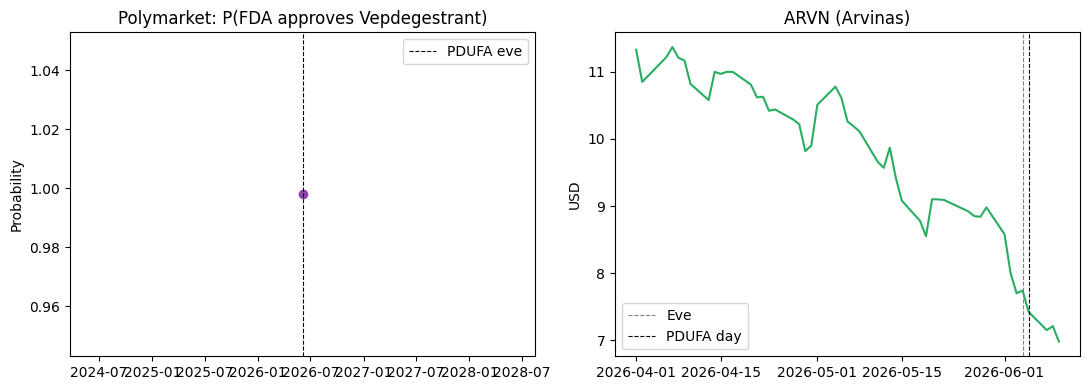

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(poly_hourly["dt"], poly_hourly["p"], color="#8e44ad", lw=1.5, marker="o")
axes[0].axvline(hedge_entry_dt, color="#27ae60", ls="--", lw=0.8, label="Hedge entry (first print)")
axes[0].axvline(EVENT_RET_DAY, color="k", ls="--", lw=0.8, label="PDUFA day")
axes[0].set_title("Polymarket: P(FDA approves Vepdegestrant)")
axes[0].set_ylabel("Probability")
axes[0].legend()

axes[1].plot(stock_close.loc["2026-04-01":"2026-06-10"], color="#27ae60", lw=1.5)
axes[1].axvline(EVENT_EVE, color="#27ae60", ls="--", lw=0.8, label="Stock entry")
axes[1].axvline(EVENT_RET_DAY, color="k", ls="--", lw=0.8, label="PDUFA day")
axes[1].set_title(f"{STOCK_TICKER} (Arvinas)")
axes[1].set_ylabel("USD")
axes[1].legend()

plt.tight_layout()
plt.show()

## 5. Variance-minimising hedge

```
Approved:     V0×(1 + ret_approve)  + N×(1 − yes_cost)
Not approved: V0×(1 + ret_reject)  − N×yes_cost

N = V_reject − V_approve
```

Negative `N` → **short YES** (lock in when approval is the better outcome for the stock).

In [7]:
V_approve = V0 * (1 + ret_if_event)
V_reject = V0 * (1 + ret_if_not)
N = V_reject - V_approve
premium = N * yes_cost

wealth_approve_hedged = V_approve + N * (1 - yes_cost)
wealth_reject_hedged = V_reject - N * yes_cost

side = "SHORT" if N < 0 else "LONG"
print(f"Hedge: {side} {abs(N):,.0f} YES contracts @ ${yes_cost:.3f}")
if premium < 0:
    print(f"Premium received: ${abs(premium):,.0f}")
else:
    print(f"Premium paid: ${premium:,.0f}")
print(f"Locked wealth (two-state): ${wealth_approve_hedged:,.0f} / ${wealth_reject_hedged:,.0f}")

Hedge: SHORT 2,352 YES contracts @ $0.999
Premium received: $2,350
Locked wealth (two-state): $95,863 / $95,863


## 6. Monte Carlo with residual (basis) risk

In [8]:
def mean_std_two_state(win_val, lose_val, p):
    m = p * win_val + (1 - p) * lose_val
    v = p * (win_val - m) ** 2 + (1 - p) * (lose_val - m) ** 2
    return m, np.sqrt(v)


def pct(x):
    return 100 * x / V0


m_unh, sd_unh = mean_std_two_state(V_approve, V_reject, p_event)
m_hed, sd_hed = mean_std_two_state(wealth_approve_hedged, wealth_reject_hedged, p_event)

event = RNG.random(N_MC) < p_event
base_ret = np.where(event, ret_if_event, ret_if_not)
noise = RNG.normal(0, resid_sigma, N_MC)
stock_sim = base_ret + noise

port_unh = V0 * (1 + stock_sim)
hedge_payoff = np.where(event, N, 0.0) - premium
port_hed = port_unh + hedge_payoff

pnl_unh = port_unh - V0
pnl_hed = port_hed - V0

var_removed = 1 - np.var(pnl_hed) / np.var(pnl_unh)
hedge_cost_usd = pnl_unh.mean() - pnl_hed.mean()
hedge_cost_bps = 1e4 * hedge_cost_usd / V0
var5_unh = np.percentile(pnl_unh, 5)
var5_hed = np.percentile(pnl_hed, 5)

## 7. Summary

In [9]:
print("=" * 60)
print("FDA PDUFA HEDGE — $100k long ARVN vs Vepdegestrant approval")
print(f"Market volume: ${volume_usd/1e3:.1f}k  |  parameters from Polymarket + yfinance")
print("=" * 60)
print(f"Market-implied P(approval)     : {p_event:.1%}  [{hedge_entry_dt.strftime('%b %d %H:%M %Z')} first print]")
print(f"ARVN if approved / if rejected : {ret_if_event:+.1%} / {ret_if_not:+.1%}")
print(f"Contract price (buy YES)       : ${yes_cost:.3f}  (mid ${yes_mid:.3f} + {spread*100:.1f}c spread)")
print(f"Hedge size                     : {N:,.0f} contracts  ({side} YES)")
print("-" * 60)
print("TWO-STATE (PDUFA-driven only)")
print(f"  Unhedged  E=${m_unh:,.0f}   sd=${sd_unh:,.0f}  ({pct(sd_unh):.1f}% of notional)")
print(f"  Hedged    E=${m_hed:,.0f}   sd=${sd_hed:,.0f}  (locked across states)")
print("-" * 60)
print("FULL MODEL (with residual / basis risk)")
print(f"  Unhedged P&L : mean ${pnl_unh.mean():,.0f}  sd ${pnl_unh.std():,.0f} ({pct(pnl_unh.std()):.1f}%)")
print(f"  Hedged   P&L : mean ${pnl_hed.mean():,.0f}  sd ${pnl_hed.std():,.0f} ({pct(pnl_hed.std()):.1f}%)")
print(f"  >> VARIANCE REMOVED        : {var_removed:.1%}")
print(f"  >> RESIDUAL (basis) risk   : {1 - var_removed:.1%}  (irreducible)")
print(f"  >> HEDGE COST              : ${hedge_cost_usd:,.0f}  ({hedge_cost_bps:+.0f} bps of notional)")
print("-" * 60)
print("TAIL (5% worst case)")
print(f"  Unhedged  : {pct(var5_unh):+.1f}%   (${var5_unh:,.0f})")
print(f"  Hedged    : {pct(var5_hed):+.1f}%   (${var5_hed:,.0f})")
print(f"  Drawdown cut by ~{pct(var5_hed - var5_unh):+.1f} pts in the tail")
print("=" * 60)
print()
print("NOTE: We hedge at the first Polymarket print (~85%), not the 99%+ close.")
print("      ARVN still fell on PDUFA day despite approval — sell-the-news basis risk.")

FDA PDUFA HEDGE — $100k long ARVN vs Vepdegestrant approval
Market volume: $49.6k  |  parameters from Polymarket + yfinance
Market-implied P(approval)     : 99.8%  [Polymarket 2026-06-04]
ARVN if approved / if rejected : -4.1% / -6.5%
Contract price (buy YES)       : $0.999  (mid $0.998 + 1.0c spread)
Hedge size                     : -2,352 contracts  (SHORT YES)
------------------------------------------------------------
TWO-STATE (PDUFA-driven only)
  Unhedged  E=$95,861   sd=$105  (0.1% of notional)
  Hedged    E=$95,863   sd=$0  (locked across states)
------------------------------------------------------------
FULL MODEL (with residual / basis risk)
  Unhedged P&L : mean $-4,136  sd $3,284 (3.3%)
  Hedged   P&L : mean $-4,134  sd $3,283 (3.3%)
  >> VARIANCE REMOVED        : 0.1%
  >> RESIDUAL (basis) risk   : 99.9%  (irreducible)
  >> HEDGE COST              : $-2  (-0 bps of notional)
------------------------------------------------------------
TAIL (5% worst case)
  Unhedged  :

## 8. Chart

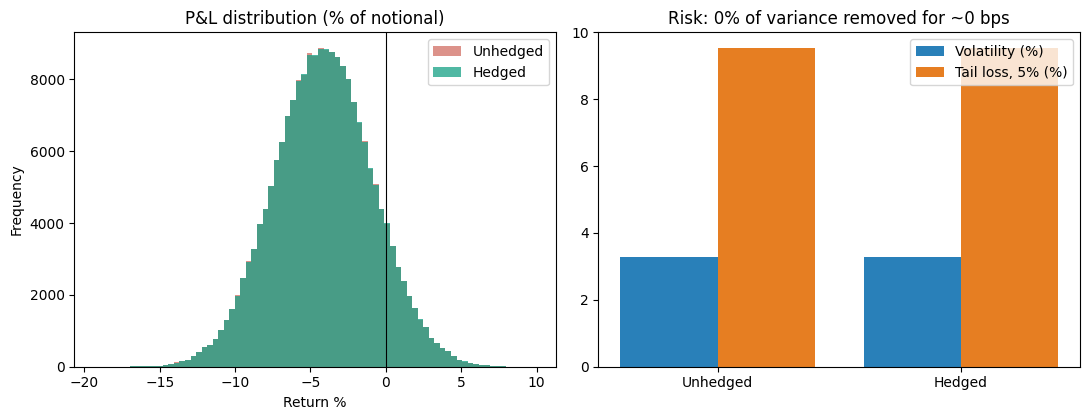

chart saved to hedge_chart_fda_arvn.png


In [10]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4.3))

bins = np.linspace(pct(pnl_unh.min()), pct(pnl_unh.max()), 80)
ax[0].hist(pct(pnl_unh), bins=bins, alpha=0.55, label="Unhedged", color="#c0392b")
ax[0].hist(pct(pnl_hed), bins=bins, alpha=0.75, label="Hedged", color="#16a085")
ax[0].axvline(0, color="k", lw=0.8)
ax[0].set_title("P&L distribution (% of notional)")
ax[0].set_xlabel("Return %")
ax[0].set_ylabel("Frequency")
ax[0].legend()

labels = ["Unhedged", "Hedged"]
sds = [pct(pnl_unh.std()), pct(pnl_hed.std())]
tails = [pct(var5_unh), pct(var5_hed)]
x = np.arange(2)
ax[1].bar(x - 0.2, sds, 0.4, label="Volatility (%)", color="#2980b9")
ax[1].bar(x + 0.2, [-t for t in tails], 0.4, label="Tail loss, 5% (%)", color="#e67e22")
ax[1].set_xticks(x)
ax[1].set_xticklabels(labels)
ax[1].set_title(f"Risk: {var_removed:.0%} of variance removed for ~{abs(hedge_cost_bps):.0f} bps")
ax[1].legend()

plt.tight_layout()
plt.savefig("hedge_chart_fda_arvn.png", dpi=140)
plt.show()
print("chart saved to hedge_chart_fda_arvn.png")